In [1]:
import cme.decision_models.confidence_accumulation as ca
import numpy as np
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import numpyro as npy
import numpyro.distributions as dist
from cme.utils import common_utils as cu
import jax
from jax import config
config.update("jax_enable_x64", False)

/home/axon/rkm160630/ritesh/computational_models_of_reasoning/cme/decision_models/confidence_accumulation.py:337: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if prior_type is not "Opposite":


In [2]:
n_states, start_width, threshold, measurement_prob, delta, mu, sigma, I, J = 7, 3, 1, 1, 1, np.asarray([[2]]), np.asarray([[1]]), 1, 5
model_type, transition_type = "Markov", "TIMESTEP"

In [3]:
I = 10
mu, sigma = np.tile(1,(I,1)), np.tile(2,(I,1))
intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
phi_0 = ca._get_initial_state(n_states, start_width,model_type=model_type, prior_type="Uniform")
intensity_matrix, phi_0

(Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
          [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
          [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
          [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
          [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
          [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
          [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]],
 
 
        [[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
          [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
          [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
          [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
          [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
          [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
          [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]],
 
 
        [[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
          [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
          [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
          [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
          [ 0. ,

In [4]:
jax.jacrev(ca.get_intensity_matrix, allow_int=True)(n_states, mu, sigma, model_type).sum()

Array(0, dtype=int32)

In [5]:
Mc, Mw, Mn = ca._get_measurement_matrix(n_states, threshold, prob=measurement_prob, model_type = model_type)
Mc

Array([[0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [6]:

t = np.asarray([[20]]) #t_s #
phi_t = ca.perform_state_transition(intensity_matrix=intensity_matrix, RT_s=t, RA_s = None, delta=delta, 
Mc = Mc, Mn = Mn, Mw = Mw, phi_0=phi_0, 
transition_type=transition_type, likelihood_type="SINGLE")

intensity_matrix.size, phi_t.size, (phi_t.size * phi_t.itemsize) / 1000000 # to get MB

(490, 70, 0.00028)

In [7]:
phi_jac = jax.jacfwd(ca.perform_state_transition)\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE")
intensity_matrix.size, phi_jac.size, (phi_jac.size * phi_jac.itemsize) / 1000000 # to get MB

(490, 34300, 0.1372)

In [8]:
intensity_matrix.squeeze().shape, phi_t.squeeze().shape, phi_jac.squeeze().shape

((10, 7, 7), (10, 7), (10, 7, 10, 7, 7))

In [9]:
import jax.scipy as sci

In [10]:
ns=np.ceil(t/delta)

def perform_state_transition(intensity_matrix, RT_s, RA_s, Mc, Mw, Mn, phi_0, delta, transition_type="RT|TIMESTEP", likelihood_type="SINGLE|JOINT"):
     
    #ns=np.floor(RT/delta) # uncomment to include all response time
    
    T_delta = sci.linalg.expm(intensity_matrix * delta)

    # uncomment to include all response time
    # T_delta_remaining = sci.linalg.expm(intensity_matrix * ((RT_remaining[...,None,None]) if not npx.isscalar(RT_remaining) else (RT_remaining)))
    T_t = ca._timestep_transition_matrix(ns, T_delta, Mn)  #uncomment if fails
    return T_t

In [11]:
fn = jax.jacrev(perform_state_transition)
compiled = jax.jit(fn, static_argnames=["transition_type", "likelihood_type"]).lower(intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, transition_type, "SINGLE"
     )
compiled.compile().cost_analysis()

[{'bytes accessed6{}': 962564.0,
  'bytes accessedout{}': 50457332.0,
  'bytes accessed0{}': 43343296.0,
  'optimal_seconds': -22.0,
  'bytes accessed2{}': 13945095.0,
  'utilization2{}': 150.0,
  'utilization10{}': 1.0,
  'utilization0{}': 362.5714416503906,
  'utilization5{}': 19.0,
  'bytes accessed11{}': 4.0,
  'bytes accessed10{}': 40.0,
  'bytes accessed1{}': 31068576.0,
  'flops': 50408256.0,
  'bytes accessed': 152436048.0,
  'utilization1{}': 252.0,
  'bytes accessed7{}': 960520.0,
  'utilization11{}': 1.0,
  'utilization7{}': 6.0,
  'bytes accessed9{}': 960400.0,
  'transcendentals': 20.0,
  'utilization3{}': 103.0,
  'bytes accessed4{}': 4808440.0,
  'bytes accessed8{}': 960400.0,
  'utilization9{}': 1.0,
  'utilization8{}': 1.0,
  'bytes accessed3{}': 7688384.0,
  'utilization4{}': 79.0,
  'bytes accessed5{}': 2885790.0,
  'utilization6{}': 10.0}]

In [12]:
phi_jac = jax.jacrev(ca.perform_state_transition)\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE")
intensity_matrix.size, phi_jac.size, (phi_jac.size * phi_jac.itemsize) / 1000000 # to get MB

(490, 34300, 0.1372)

In [13]:
intensity_matrix.shape, phi_jac.shape

((10, 1, 7, 7), (10, 1, 7, 1, 10, 1, 7, 7))

In [14]:
jax.jacfwd(jax.jacrev(ca.perform_state_transition))\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE").size

16807000

In [15]:
likl = ca.likelihood(intensity_matrix, phi_0, delta, t, 
                          np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
                          model_type)
likl.shape

(10, 1)

In [16]:

likl = jax.jacrev(ca.likelihood)(intensity_matrix, phi_0, delta, t, 
                          np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
                          model_type)
likl.shape

(10, 1, 10, 1, 7, 7)

In [17]:
likl_lower = jax.jacrev(ca.likelihood)(intensity_matrix, phi_0, delta, t, 
                          np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
                          model_type)

In [18]:
import jax.numpy as npx
def likelihood(intensity_matrix, phi_0, delta, RT_s, RA_s, Mc, Mw, Mn, transition_type="RT|TIMESTEP", likelihood_type="SINGLE|JOINT", model_type="Markov|Quantum"):

    phi_t = perform_state_transition(intensity_matrix, RT_s, RA_s, Mc, Mw, Mn, phi_0, delta, 
                                     transition_type=transition_type, likelihood_type=likelihood_type)

    if likelihood_type == "SINGLE":
        RA = RA_s
        RT_cond = RT_s
    else:
        raise Exception(f"Please select one of {likelihood_type} values for likelihood_type variable")


    P_t_c = (Mc @ phi_t)
    P_t_w = (Mw @ phi_t)
    P_t = npx.where(RA[...,None,None]==1, P_t_c, P_t_w)

    if model_type == "Markov":
        #P_t_c = (Mc @ phi_t).sum(axis=(-2,-1))
        #P_t_w = (Mw @ phi_t).sum(axis=(-2,-1))

        P_t = P_t.sum(axis=(-2,-1)) # Adding over states
        
        #P_t = npx.where(RA==1, P_t_c, P_t_w)
        
    elif model_type == "Quantum":
        #P_t_c = (npx.abs(Mc @ phi_t)**2).sum(axis=(-2,-1))
        #P_t_w = (npx.abs(Mw @ phi_t)**2).sum(axis=(-2,-1))

        P_t = (npx.abs(P_t)**2).sum(axis=(-2,-1)) #Adding over states
        

        #P_t = npx.where(RA==1, P_t_c, P_t_w)
        
    else:
        raise Exception(f"Please select one of {model_type}")
  
    
    P_t = npx.where(RT_cond <= 0, 0, P_t)

    return npx.log(P_t).sum() #npx.log(npx.sum(P_t)) # summing over all participants and trials

In [19]:
fn = jax.grad(likelihood)
cost = jax.jit(fn, static_argnames=["transition_type", "likelihood_type", "model_type"]).lower(
    intensity_matrix, phi_0, delta, t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     ).compile().cost_analysis()
cost

[{'flops': 360505.0,
  'bytes accessed1{}': 165805.0,
  'bytes accessed10{}': 40.0,
  'utilization5{}': 17.0,
  'bytes accessed11{}': 4.0,
  'utilization0{}': 327.57147216796875,
  'utilization10{}': 1.0,
  'utilization2{}': 142.0,
  'bytes accessed2{}': 92375.0,
  'optimal_seconds': -1.0,
  'bytes accessed0{}': 243136.0,
  'bytes accessed6{}': 4044.0,
  'bytes accessedout{}': 312257.0,
  'utilization4{}': 72.0,
  'utilization6{}': 8.0,
  'utilization8{}': 1.0,
  'utilization9{}': 1.0,
  'bytes accessed3{}': 14744.0,
  'bytes accessed5{}': 8434.0,
  'bytes accessed8{}': 1960.0,
  'bytes accessed4{}': 12156.0,
  'utilization3{}': 94.0,
  'transcendentals': 20.0,
  'bytes accessed9{}': 40.0,
  'utilization7{}': 5.0,
  'utilization11{}': 1.0,
  'bytes accessed7{}': 2040.0,
  'utilization1{}': 247.0,
  'bytes accessed': 808283.0}]

In [20]:
str1 = jax.make_jaxpr(fn,static_argnums=[8,9,10])(intensity_matrix, phi_0, delta, t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     )
len(str1.pretty_print())

90962

In [21]:
fn_j = jax.jit(fn, static_argnames=["transition_type", "likelihood_type", "model_type"]).lower(
    intensity_matrix, phi_0, delta, t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     )
jax.tree.leaves(fn)


[<function __main__.likelihood(intensity_matrix, phi_0, delta, RT_s, RA_s, Mc, Mw, Mn, transition_type='RT|TIMESTEP', likelihood_type='SINGLE|JOINT', model_type='Markov|Quantum')>]

In [22]:
def _get_step_size(alpha, tau, sigma):
   return alpha * npx.sqrt(sigma) * npx.sqrt(tau)

def _get_n_states(alpha, theta, tau, sigma):
    #sigma = npx.sqrt(sigma)#.squeeze()
    step_size = _get_step_size(alpha, tau, sigma)
    n_states = 2 * int(theta/step_size) + 1 #np.round(theta/delta_state) #2 * round(theta/delta_state) + 1 # #
    return n_states

In [23]:
def _create_Wiener_Q(n_states, alpha, tau, sigma, mu):
    #if mu > sigma:
    #   raise Exception("Drift Rate (mu) should be smaller than Diffusion Rate (sigma)")
    Q = npx.zeros((n_states, n_states))
    rows_ = npx.arange(1,n_states)
    cols_ = npx.arange(0,n_states-1)
    Q = Q.at[rows_,cols_].set(1/(2*alpha)*(1-mu*npx.sqrt(tau)/sigma**2))
    Q = Q.at[cols_, rows_].set(1/(2*alpha)*(1+mu*npx.sqrt(tau)/sigma**2))
    Q = Q.at[npx.arange(n_states), npx.arange(n_states)].set(1-(1/alpha))
    Q = Q.at[0,1].set(0)
    Q = Q.at[-1,-2].set(0)
    return Q

In [24]:
def disc_likl(n_states, dis_tran, initial_state):
    m = n_states-1
    #P  = npx.eye(2)
    R = dis_tran[...,1:m, [0, -1]]
    Q = dis_tran[...,1:n_states-1, 1:n_states-1]
    #Z = stats.uniform().rvs((1,Q.shape[0]))
    #Z = Z/Z.sum()
    num_arr_i = []
    
    for i_s_i, n_i, Q_i, R_i in zip(initial_state, ns1, Q, R): #global variable
        num_arr_ij = []
        for n_ij in n_i:
            num = npx.array(i_s_i[0]) @ npx.linalg.matrix_power(Q_i[0], n_ij) @ R_i[0]
            num_arr_ij.append(num)
        num_arr_i.append(num_arr_ij)

    num = npx.asarray(num_arr_i)
    den = initial_state @ npx.linalg.matrix_power(npx.eye(n_states-2) - Q, -1) @ R
    #return npx.log(num/den).sum()
    return num/den

In [25]:
theta, alpha, tau, I, J = 11, 1.5, 0.01, 10, 50

mu, sigma = npx.asarray([1.2]), npx.asarray([1])

n_states = _get_n_states(alpha, theta, tau, sigma[0])
dis_tran = _create_Wiener_Q(n_states, alpha, tau, sigma[0], mu)
dis_tran.shape

(147, 147)

In [26]:
def create_Q(I, n_states,alpha, tau, sigma, mus):
    Q = []
    for _, mu in zip(range(I),mus):
        Q.append(_create_Wiener_Q(n_states,alpha, tau, sigma, mu))
    return np.stack(Q)[:,None,...]
mus = np.tile(1.2,(I,1))
Q = create_Q(I, n_states,alpha, tau, sigma, mus)
Q.shape 

(10, 1, 147, 147)

In [27]:
stats.uniform().rvs((I,1,1,n_states-2)).shape

(10, 1, 1, 145)

In [28]:
ns1 = np.ceil(np.tile(1.2,(I,J)) / tau).astype(int)

def dis_likl(n_states, Q, initial_state):
    arr = disc_likl(n_states, Q, initial_state)
    return (npx.asarray(arr))#.sum()
fn_disc_likl = dis_likl(n_states, Q, stats.uniform().rvs((I,1,1,n_states-2)))

fn_disc_likl.sum()

Array(1.041831, dtype=float32)

#dis_tran = _create_Wiener_Q(n_states,alpha, tau, sigma, mu)
mu, sigma = npx.asarray([1.2]), npx.asarray([1])
fn_disc = jax.jacrev(_create_Wiener_Q, allow_int=True)

#fn_disc(n, n_states, dis_tran, stats.uniform().rvs((1,n_states-2)))#.shape
fn_disc(n_states,alpha, tau, sigma, mu).sum()

jax.tree.leaves(fn_disc)

In [29]:
fn_disc = jax.jacrev(dis_likl, allow_int=True)
fn_disc(n_states, Q, stats.uniform().rvs((I,1,1,n_states-2))).sum()


Array(0, dtype=int32)

In [30]:
jax.jit(fn_disc, static_argnums=[0]).lower(n_states, Q, stats.uniform().rvs((I,1,1,n_states-2))).cost_analysis()

{'bytes accessed': 4004.0,
 'utilization0{}': 1.0,
 'bytes accessed0{}': 4.0,
 'bytes accessedout{}': 4000.0}

In [31]:
ns1 = np.ceil(np.tile(1.2,(I,J)) / tau).astype(int)

jax.jit(dis_likl, static_argnums=[0]).lower(n_states, Q, stats.uniform().rvs((I,1,1,n_states-2))).cost_analysis()

{'flops': 27582078976.0,
 'bytes accessed': 1296445440.0,
 'optimal_seconds': -1.0,
 'utilization0{}': 7644.0087890625,
 'utilization1{}': 5565.0,
 'bytes accessed0{}': 433810400.0,
 'bytes accessed1{}': 425505184.0,
 'bytes accessedout{}': 437095744.0,
 'utilization47{}': 10.0,
 'bytes accessed35{}': 80.0,
 'utilization36{}': 10.0,
 'bytes accessed23{}': 80.0,
 'bytes accessed17{}': 80.0,
 'utilization33{}': 10.0,
 'bytes accessed14{}': 80.0,
 'utilization24{}': 10.0,
 'bytes accessed7{}': 480.0,
 'utilization11{}': 10.0,
 'utilization26{}': 10.0,
 'bytes accessed18{}': 80.0,
 'bytes accessed40{}': 80.0,
 'utilization39{}': 10.0,
 'bytes accessed29{}': 80.0,
 'bytes accessed15{}': 80.0,
 'bytes accessed46{}': 80.0,
 'utilization28{}': 10.0,
 'utilization9{}': 11.0,
 'bytes accessed27{}': 80.0,
 'bytes accessed4{}': 480.0,
 'utilization29{}': 10.0,
 'bytes accessed39{}': 80.0,
 'bytes accessed43{}': 80.0,
 'utilization19{}': 10.0,
 'bytes accessed24{}': 80.0,
 'bytes accessed28{}': 80.

# Discrete Model

In [32]:
import itertools as iter
n_states_arr, start_width_arr, measurement_prob,  = [11, 51, 101], [2, 7, 11], 0.8
#threshold, measurement_prob, drift_rate, diffusion_rate = 1, 1, np.tile(1,(I,1)), np.tile(2,(I,1))
#model_type = "Quantum"
#transition_type="RT"
I_arr, J_arr = [20, 400], [50] #,1000,10000
transition_type_arr = ["TIMESTEP"]#, "TIMESTEP"]
model_type_arr = ["Markov"]
df_memory1 = []
#mu, sigma = npx.asarray([1.2]), npx.asarray([1])
for (n_states, start_width), (I, J, transition_type, model_type) in iter.product(zip(n_states_arr, start_width_arr), iter.product(I_arr, J_arr, transition_type_arr, model_type_arr)):
    print(n_states, start_width, I, J, transition_type, model_type)
    mus, sigma = np.tile(1.2,(I,1)), npx.asarray([1])

    theta, alpha, tau = n_states, 1.5, 0.1

    n_states = _get_n_states(alpha, theta, tau, sigma[0])
    Q = create_Q(I, n_states,alpha, tau, sigma, mus)
    random_ts = dist.Uniform(delta, 40/delta).sample(key=cu.get_rng(), sample_shape=(I,J))
    ns1 = np.ceil(random_ts / tau).astype(int)

    #fn_g = jax.jacrev(dis_likl, allow_int=True)
    #random_ts = dist.Uniform(tau, 40/tau).sample(key=cu.get_rng(), sample_shape=(I,J))
    #ns1 = np.ceil(random_ts/tau).astype(int) #1 sec
    #cost_st_tr_g = jax.jit(fn_g, static_argnums=[0,1,2,3,4]).lower(I, J, n_states, alpha, tau, sigma[0], mu, stats.uniform().rvs((1,n_states-2))).cost_analysis()

    fn = dis_likl
    cost_st_tr = jax.jit(dis_likl, static_argnums=[0]).lower(n_states, Q, stats.uniform().rvs((I,1,1,n_states-2))).cost_analysis()


    df_t1 = pd.DataFrame({  
        "Model":model_type,
        "Transition":"External" if transition_type == "RT" else "Internal",
        "I":I,
        "J":J,
        #"States":f"{theta}({n_states})",
        "States":f"{theta}",
        "Calculated_States":f"{n_states}",
        #"bytes_accessed_g": 0, #[cost_st_tr_g["bytes accessed"] / 1000000000], # to get GB
        #"flops_g": [cost_st_tr_g["flops"]/ 1000000000] , # to get gigaflops

        "bytes_accessed": [cost_st_tr["bytes accessed"] / 1000000000], # to get GB
        "flops": [cost_st_tr["flops"]/ 1000000000] , # to get gigaflops

    #    "matrix_orig":[intensity_matrix.size], 
    #    "matrix_jac":[phi_jac.size], 
    #    "matrix_memory":[(intensity_matrix.size * phi_jac.itemsize) / 1000000],
    #    "jac_memory":[(phi_jac.size * phi_jac.itemsize) / 1000000] # to get MB
    })
    print(cost_st_tr["bytes accessed"] / 1000000000)#, cost_st_tr_g["bytes accessed"] / 1000000000)
    #print(intensity_matrix.size, phi_jac.size)
    df_memory1.append(df_t1)
df_memory1 = pd.concat(df_memory1).assign(state="Discrete")
df_memory1

11 2 20 50 TIMESTEP Markov
0.27605936
11 2 400 50 TIMESTEP Markov
5.549969408
51 7 20 50 TIMESTEP Markov
6.1248
51 7 400 50 TIMESTEP Markov
123.473747968
101 11 20 50 TIMESTEP Markov
24.11308032
101 11 400 50 TIMESTEP Markov
487.194394624


,Model,Transition,I,J,States,Calculated_States,bytes_accessed,flops,state
0,Markov,Internal,20,50,11,47,0.276059,1.838752,Discrete
0,Markov,Internal,400,50,11,47,5.549969,37.012369,Discrete
0,Markov,Internal,20,50,51,215,6.124800,193.909391,Discrete
0,Markov,Internal,400,50,51,215,123.473748,3917.934756,Discrete
0,Markov,Internal,20,50,101,425,24.113080,1516.838978,Discrete
0,Markov,Internal,400,50,101,425,487.194395,30706.126291,Discrete


with sns.plotting_context("talk", font_scale=1.3):
    f = sns.catplot(
                df_memory1.query("Model=='Markov'").melt(id_vars=df_memory1.columns.drop(["bytes_accessed_g", "bytes_accessed"]), var_name="Function") \
                .assign(**{"Function": lambda df: df["Function"].map({"bytes_accessed_g":"Likelihood Gradient", "bytes_accessed":"Likelihood"})})
                .assign(I = lambda df: df.I.astype(str), value = lambda df: np.ceil(df.value)),
    x="States",
    y="value",
    hue="I",
    col="Function", aspect=1.3, col_order=["Likelihood"],#, "Likelihood Gradient"],
    kind="bar", #facet_kws={"sharey":True}
    )
    #f.set(yscale="log")#, xscale="log")
    f.set_ylabels("Memory (GB)")
    f.set_xlabels("States")
    f.set_titles(col_template="{col_name}")
    #f.refline(y=1000, alpha=0.5)
    #f.refline(y=100, alpha=0.5)
    #f.refline(y=40)
    f.legend.set_title("Participants")
    #f.legend.set_bbox_to_anchor((0.25,0.6))
    f.legend.set_alpha(.1)
    f.legend.set_frame_on(True)

    
    #f.axes[0,0].text(y=120, x=2, s="100 GB", alpha=0.5, size=14)
    #f.axes[0,0].text(y=1200, x=2.175, s="1 TB", alpha=0.5, size=14)
    #f.axes[0,0].text(y=45, x=1.1, s="NVIDIA RTX A6000 (40 GB)", alpha=0.5, size=14)

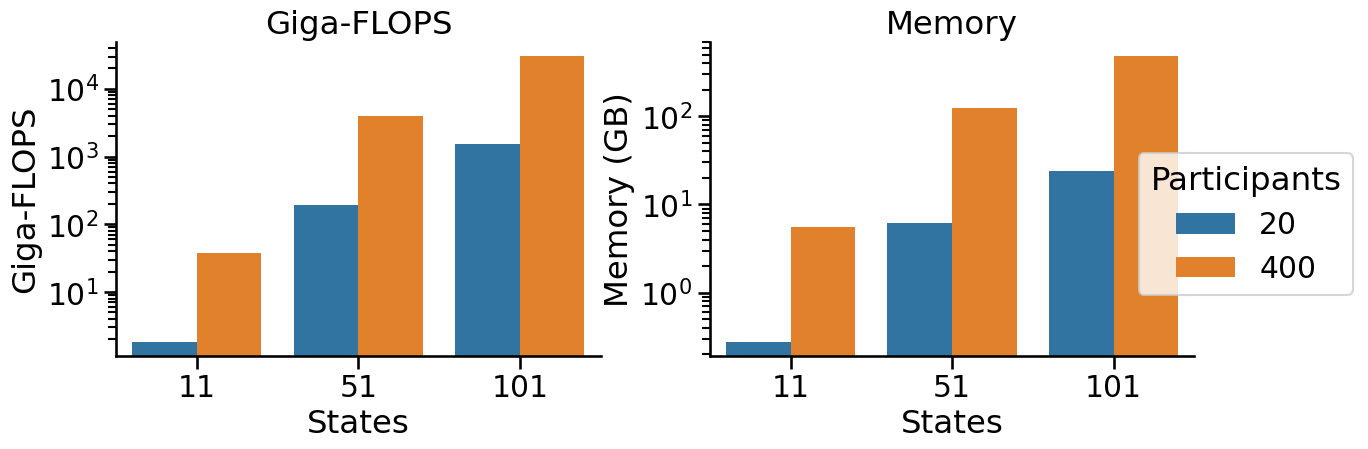

In [33]:
with sns.plotting_context("talk", font_scale=1.3):
    f = sns.catplot(
                df_memory1.query("Model=='Markov'").melt(id_vars=df_memory1.columns.drop(["flops", "bytes_accessed"]), var_name="Function") \
                .assign(**{"Function": lambda df: df["Function"].map({"flops":"Giga-FLOPS", "bytes_accessed":"Memory"})})
                .assign(I = lambda df: df.I.astype(str)),
    x="States",
    y="value",
    hue="I",
    col="Function", aspect=1.3, col_order=["Giga-FLOPS", "Memory"],#, "Likelihood Gradient"],
    kind="bar", sharey=False,
    )
    f.set(yscale="log")#, xscale="log")
    f.set_ylabels("Giga-FLOPS", clear_inner=False)
    f.axes[0,1].set_ylabel("Memory (GB)")
    f.set_xlabels("States")
    f.set_titles(col_template="{col_name}")
    #f.refline(y=1000, alpha=0.5)
    #f.refline(y=100, alpha=0.5)
    #f.refline(y=40)
    f.legend.set_title("Participants")
    #f.legend.set_bbox_to_anchor((0.25,0.6))
    f.legend.set_alpha(.1)
    f.legend.set_frame_on(True)

    
    #f.axes[0,0].text(y=120, x=2, s="100 GB", alpha=0.5, size=14)
    #f.axes[0,0].text(y=1200, x=2.175, s="1 TB", alpha=0.5, size=14)
    #f.axes[0,0].text(y=45, x=1.1, s="NVIDIA RTX A6000 (40 GB)", alpha=0.5, size=14)

In [36]:
p_s = perform_state_transition
likl = likelihood
import itertools as iter
n_states_arr, rw, start_width_arr, delta, measurement_prob,  = [11, 51, 101], [1, 5, 10], [2, 7, 11], 0.5, 0.8
threshold, measurement_prob, drift_rate, diffusion_rate = 1, 1, np.tile(1,(I,1)), np.tile(2,(I,1))
#model_type = "Quantum"
#transition_type="RT"
I_arr, J_arr = [20, 400], [50] #,1000,10000
transition_type_arr = ["TIMESTEP"]#, "TIMESTEP"]
model_type_arr = ["Markov", "Quantum"]
df_memory = []
for (n_states, start_width, rw), (I, J, transition_type, model_type) in iter.product(zip(n_states_arr, start_width_arr, rw), iter.product(I_arr, J_arr, transition_type_arr, model_type_arr)):
    print(n_states, start_width, I, J, transition_type, model_type)
    
    mu, sigma = np.tile(1,(I,1)), np.tile(2,(I,1))
    Mc, Mw, Mn = ca._get_measurement_matrix(n_states, response_width = rw, prob=measurement_prob, model_type = model_type)
    Mid1 = (ns-2*rw)//2
    phi_0 = ca._get_initial_state(n_states, Mid1-1, model_type=model_type, prior_type="Uniform")
    
    random_ts = dist.Uniform(delta, 40/delta).sample(key=cu.get_rng(), sample_shape=(I,J))
    
    intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
    
    #fn_g = jax.jacrev(perform_state_transition, holomorphic=True if model_type=="Quantum" else False)
    #fn_g_jit = jax.jit(fn_g, static_argnames=["delta", "transition_type", "likelihood_type"])
    #cost_st_tr_g = fn_g_jit.lower(intensity_matrix, t, None, 
    #        Mc, Mw, Mn, 
    #        phi_0, delta, transition_type, "SINGLE"
    #        ).cost_analysis()
    ns=np.ceil(random_ts/delta)
    fn_g = jax.grad(likl)#, holomorphic=True if model_type == "Quantum" else False)
    cost_st_tr_g = jax.jit(fn_g, static_argnames=["transition_type", "likelihood_type", "model_type"]).lower(
    intensity_matrix, phi_0, delta, random_ts,#t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     ).cost_analysis()#.compile()[0]

    
    # fn_s = p_s
    # fn_s_jit = jax.jit(fn_s, static_argnames=["delta", "transition_type", "likelihood_type"])
    # cost_st_tr_s = fn_s_jit.lower(intensity_matrix, random_ts, #t, 
    #                               None, 
    #                                 Mc, Mw, Mn, 
    #                                 phi_0, delta, transition_type, "SINGLE"
    #                                 ).cost_analysis() #.compile()[0] 

    fn = likl
    cost_st_tr = jax.jit(fn, static_argnames=["transition_type", "likelihood_type", "model_type"]).lower(
    intensity_matrix, phi_0, delta, random_ts, #t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     ).cost_analysis()#.compile()[0]


    df_t = pd.DataFrame({  
        "Model":model_type,
        "Transition":"External" if transition_type == "RT" else "Internal",
        "I":I,
        "J":J,
        "States":n_states,
        "bytes_accessed_g": [cost_st_tr_g["bytes accessed"] / 1000000000], # to get GB
        "flops_g": [cost_st_tr_g["flops"]/ 1000000000] , # to get gigaflops

        #"bytes_accessed_s": [cost_st_tr_s["bytes accessed"] / 1000000000], # to get GB
        #"flops_s": [cost_st_tr_s["flops"]/ 1000000000] , # to get gigaflops

        "bytes_accessed": [cost_st_tr["bytes accessed"] / 1000000000], # to get GB
        "flops": [cost_st_tr["flops"]/ 1000000000] , # to get gigaflops

    #    "matrix_orig":[intensity_matrix.size], 
    #    "matrix_jac":[phi_jac.size], 
    #    "matrix_memory":[(intensity_matrix.size * phi_jac.itemsize) / 1000000],
    #    "jac_memory":[(phi_jac.size * phi_jac.itemsize) / 1000000] # to get MB
    })
    print(cost_st_tr["bytes accessed"] / 1000000000, cost_st_tr_g["bytes accessed"] / 1000000000)
    #print(intensity_matrix.size, phi_jac.size)
    df_memory.append(df_t)
df_memory = pd.concat(df_memory).assign(state="Continuous")
df_memory

11 2 20 50 TIMESTEP Markov
0.025211548 0.083466064
11 2 20 50 TIMESTEP Quantum
0.053237816 0.196803808
11 2 400 50 TIMESTEP Markov
0.498234208 1.973634816
11 2 400 50 TIMESTEP Quantum
1.068087872 4.544800768
51 7 20 50 TIMESTEP Markov
0.532057376 1.768059392
51 7 20 50 TIMESTEP Quantum
1.144875392 4.192320768
51 7 400 50 TIMESTEP Markov
10.692276224 42.3194624
51 7 400 50 TIMESTEP Quantum
22.927732736 97.555423232
101 11 20 50 TIMESTEP Markov
2.108017792 7.019153408
101 11 20 50 TIMESTEP Quantum
4.487819264 16.43095552
101 11 400 50 TIMESTEP Markov
41.932324864 166.02128384
101 11 400 50 TIMESTEP Quantum
89.896648704 382.080319488


,Model,Transition,I,J,States,bytes_accessed_g,flops_g,bytes_accessed,flops,state
0,Markov,Internal,20,50,11,0.083466,0.092032,0.025212,0.033249,Continuous
0,Quantum,Internal,20,50,11,0.196804,0.094201,0.053238,0.033010,Continuous
0,Markov,Internal,400,50,11,1.973635,1.847055,0.498234,0.655799,Continuous
0,Quantum,Internal,400,50,11,4.544801,1.888749,1.068088,0.664842,Continuous
0,Markov,Internal,20,50,51,1.768059,8.873970,0.532057,3.218324,Continuous
0,Quantum,Internal,20,50,51,4.192321,8.968589,1.144875,3.243776,Continuous
0,Markov,Internal,400,50,51,42.319462,179.377046,10.692276,64.908222,Continuous
0,Quantum,Internal,400,50,51,97.555423,180.345504,22.927733,65.132786,Continuous
0,Markov,Internal,20,50,101,7.019153,69.855551,2.108018,25.332926,Continuous
0,Quantum,Internal,20,50,101,16.430956,69.281268,4.487819,25.118999,Continuous


In [38]:
df_memory.melt(id_vars=df_memory.columns.drop(["flops", "bytes_accessed"]))

,Model,Transition,I,J,States,bytes_accessed_g,flops_g,state,variable,value
0,Markov,Internal,20,50,11,0.083466,0.092032,Continuous,bytes_accessed,0.025212
1,Quantum,Internal,20,50,11,0.196804,0.094201,Continuous,bytes_accessed,0.053238
2,Markov,Internal,400,50,11,1.973635,1.847055,Continuous,bytes_accessed,0.498234
3,Quantum,Internal,400,50,11,4.544801,1.888749,Continuous,bytes_accessed,1.068088
4,Markov,Internal,20,50,51,1.768059,8.873970,Continuous,bytes_accessed,0.532057
5,Quantum,Internal,20,50,51,4.192321,8.968589,Continuous,bytes_accessed,1.144875
6,Markov,Internal,400,50,51,42.319462,179.377046,Continuous,bytes_accessed,10.692276
7,Quantum,Internal,400,50,51,97.555423,180.345504,Continuous,bytes_accessed,22.927733
8,Markov,Internal,20,50,101,7.019153,69.855551,Continuous,bytes_accessed,2.108018
9,Quantum,Internal,20,50,101,16.430956,69.281268,Continuous,bytes_accessed,4.487819


(0.036715045212807454, 1000)

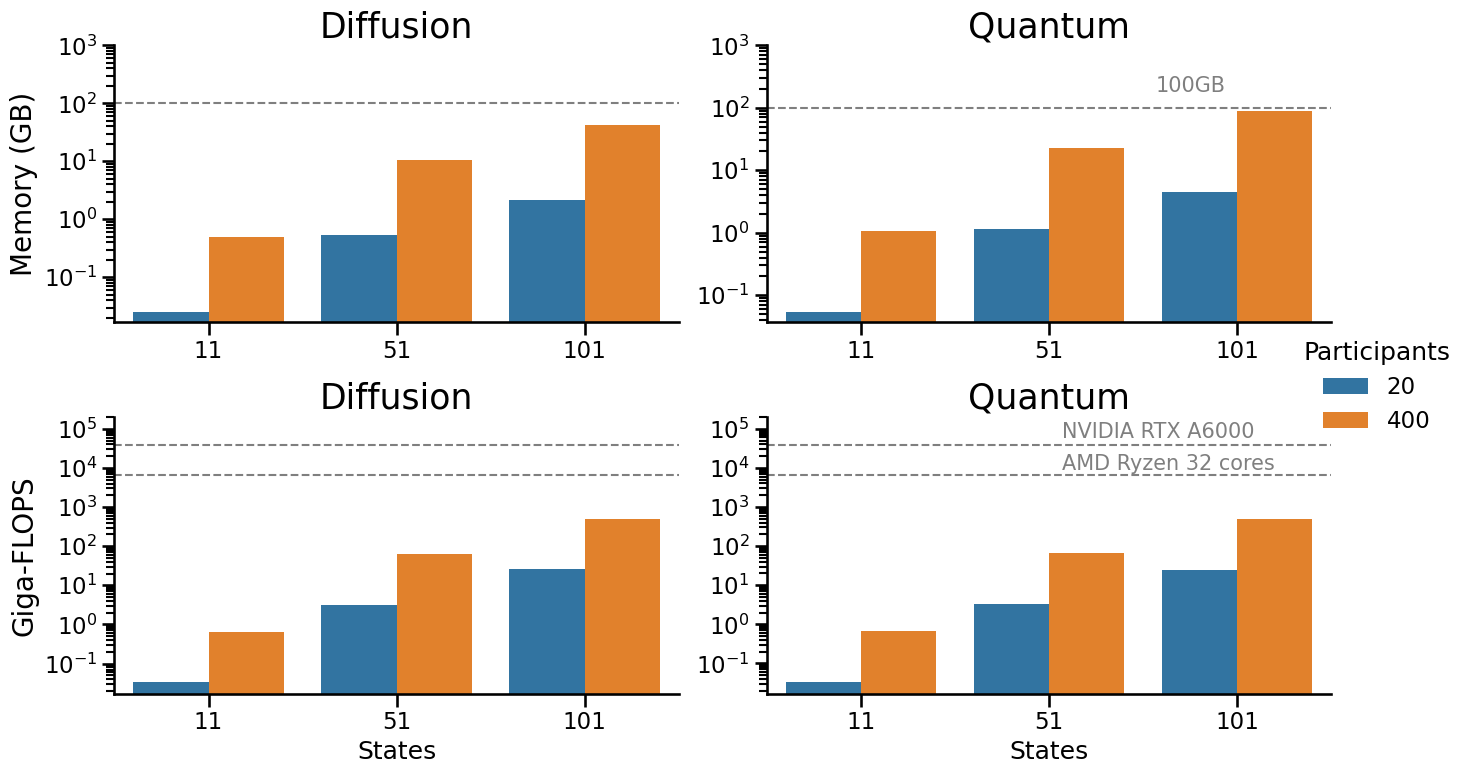

In [77]:
with sns.plotting_context("talk"):
    f = sns.catplot(df_memory.assign(Model = lambda df: df.Model.map({"Markov":"Diffusion", "Quantum":"Quantum"})).melt(id_vars=df_memory.columns.drop(["flops", "bytes_accessed"])).astype({"States":"category", "I":"category"}), 
            hue="I", x="States", y="value", row="variable", col="Model",
            kind="bar", sharex=False, sharey=False, aspect=1.7, height=4,
            )
f.set(yscale="log")
f.legend.set_title("Participants")
f.axes[0,0].set_ylabel("Memory (GB)", size=20)
f.axes[1,0].set_ylabel("Giga-FLOPS", size=20)
f.set_titles("{col_name}", size=25)


f.axes[1,1].text(y=38.71*1500, x=1.07, s="NVIDIA RTX A6000", alpha=0.5, size=15) #https://www.techpowerup.com/gpu-specs/rtx-a6000.c3686 
f.axes[1,1].text(y=8900, x=1.07, s="AMD Ryzen 32 cores", alpha=0.5, size=15) #https://www.techpowerup.com/cpu-specs/ryzen-threadripper-pro-3975wx.c2315#:~:text=6%2C451.2,GFLOPS


f.axes[1,0].axhline(y=38.71*1000, ls="--", alpha=0.5, color="black") #38.71 TFLOPS
f.axes[1,0].axhline(y=6451.2, ls="--", alpha=0.5, color="black") # AMD Threadripper
f.axes[1,1].axhline(y=38.71*1000, ls="--", alpha=0.5, color="black") #38.71 TFLOPS
f.axes[1,1].axhline(y=6451.2, ls="--", alpha=0.5, color="black") # AMD Threadripper

f.axes[1,0].set_ylim((None, 200000))
f.axes[1,1].set_ylim((None, 200000))



f.axes[0,0].axhline(y=100, ls="--", alpha=0.5, color="black")
f.axes[0,1].axhline(y=100, ls="--", alpha=0.5, color="black")
f.axes[0,1].text(x=1.57, y=180, s="100GB", alpha=0.5, color="black", size=15)
f.axes[0,0].set_ylim((None, 1000))
f.axes[0,1].set_ylim((None, 1000))

phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Uniform")
    random_ts = dist.Uniform(delta, 40/delta).sample(key=cu.get_rng(), sample_shape=(I,J))
    intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
    phi_jac = jax.jacfwd(ca.perform_state_transition, holomorphic=True if model_type=="Quantum" else False)(intensity_matrix, random_ts, None, delta, 
    Mc, Mn, Mw, phi_0, transition_type, "SINGLE")

f = sns.relplot(
            df_memory.melt(id_vars=df_memory.columns.drop(["bytes_accessed_g", "bytes_accessed"]), var_name="Memory(GB)") \
            .assign(**{"Memory(GB)": lambda df: df["Memory(GB)"].map({"bytes_accessed_g":"Jacobian of Transition Fn", "bytes_accessed":"Transition Function"})})
            ,
style="States",
y="value",
col="Model",
x="I",
hue="Memory(GB)",
kind="line", facet_kws={"sharey":True}
)
f.set(yscale="log", xscale="log")
f.set_ylabels("Memory (GB)")
f.set_xlabels("Number of Participants")
f.set_titles(col_template="{col_name}")

with sns.plotting_context("talk", font_scale=1.3):
    f = sns.catplot(
                df_memory.query("Model=='Quantum'").melt(id_vars=df_memory.columns.drop(["bytes_accessed_s", "bytes_accessed_g", "bytes_accessed"]), var_name="Function") \
                .assign(**{"Function": lambda df: df["Function"].map({"bytes_accessed_s":"Transition", "bytes_accessed_g":"Likelihood Gradient", "bytes_accessed":"Likelihood"})})
                .assign(I = lambda df: df.I.astype("str"), value = lambda df: np.ceil(df.value)),
    x="States",
    y="value",
    hue="I",
    col="Function", aspect=1.3, col_order=["Likelihood", "Likelihood Gradient"],
    kind="bar", #facet_kws={"sharey":True}
    )
    #f.set(yscale="log")#, xscale="log")
    f.set_ylabels("Memory (GB)")
    f.set_xlabels("States")
    f.set_titles(col_template="{col_name}")
    #f.refline(y=1000, alpha=0.5)
    #f.refline(y=50, alpha=0.5)
    #f.refline(y=40)
    f.legend.set_title("Participants")
    f.legend.set_bbox_to_anchor((0.25,0.6))
    f.legend.set_alpha(.2)
    f.legend.set_frame_on(True)

    
    #f.axes[0,0].text(y=55, x=2, s="50 GB", alpha=0.5, size=14)
    #f.axes[0,0].text(y=1200, x=2.175, s="1 TB", alpha=0.5, size=14)
    #f.axes[0,0].text(y=45, x=1.1, s="NVIDIA RTX A6000 (40 GB)", alpha=0.5, size=14)

with sns.plotting_context("talk", font_scale=1.4):
    f = sns.catplot(
                df_memory.query("Model=='Quantum'").melt(id_vars=df_memory.columns.drop(["flops_g", "flops_s", "flops"]), var_name="FLOPS") \
                .assign(FLOPS = lambda df: df.FLOPS.map({"flops_g":"Likelihood Gradient", "flops":"Likelihood", "flops_s":"Transition Function"})) 
                .assign(I = lambda df: df.I.astype(str))
                ,
    x="States",
    y="value",
    hue="I", col_order=["Likelihood", "Likelihood Gradient"],
    col="FLOPS",
    kind="bar", aspect=1.5, legend=False
    )
    f.set(yscale="log")
    f.set_ylabels("Giga FLOPS")
    f.set_xlabels("States")
    f.set_titles(col_template="")
    f.refline(y=38.71*1000) #38.71 TFLOPS
    f.refline(y=6451.2) # AMD Threadripper
    #f.legend.set_title("Participants")
    f.axes[0,0].text(y=38.71*1500, x=1.27, s="NVIDIA RTX A6000", alpha=0.5, size=14) #https://www.techpowerup.com/gpu-specs/rtx-a6000.c3686 
    f.axes[0,0].text(y=8900, x=1.27, s="AMD Ryzen 32 cores", alpha=0.5, size=14) #https://www.techpowerup.com/cpu-specs/ryzen-threadripper-pro-3975wx.c2315#:~:text=6%2C451.2,GFLOPS

f = sns.relplot(
            df_memory.melt(id_vars=df_memory.columns.drop(["flops_g", "flops"]), var_name="FLOPS") \
            .assign(FLOPS = lambda df: df.FLOPS.map({"flops_g":"Jacobian of Transition Fn", "flops":"Transition Function"})) 
            ,
style="States",
y="value",
col="Model",
x="I",
hue="FLOPS",
kind="line", facet_kws={"sharey":True}
)
f.set(yscale="log")

In [92]:
df_memory_plot = pd.concat([df_memory.assign(state="Continuous"), df_memory1.assign(state="Discrete")])
df_memory_plot

,Model,Transition,I,J,States,bytes_accessed_g,flops_g,bytes_accessed,flops,state,Calculated_States
0,Markov,Internal,20,50,11,0.082890,0.091230,0.024952,0.032773,Continuous,NaN
0,Markov,Internal,400,50,11,1.969985,1.841959,0.497718,0.654851,Continuous,NaN
0,Markov,Internal,20,50,51,1.782920,8.969008,0.535771,3.249895,Continuous,NaN
0,Markov,Internal,400,50,51,42.344870,179.537428,10.698556,64.961626,Continuous,NaN
0,Markov,Internal,20,50,101,6.987824,69.459198,2.100182,25.201023,Continuous,NaN
0,Markov,Internal,400,50,101,166.227018,1391.948595,41.983803,504.598823,Continuous,NaN
0,Markov,Internal,20,50,11,NaN,NaN,0.310661,2.098280,Discrete,47
0,Markov,Internal,400,50,11,NaN,NaN,6.212328,41.971429,Discrete,47
0,Markov,Internal,20,50,51,NaN,NaN,6.865773,220.214477,Discrete,215
0,Markov,Internal,400,50,51,NaN,NaN,138.369122,4447.043322,Discrete,215


In [2]:
#df_memory_plot.to_csv("memory_plot_0_5_0_1.csv")
df_memory_plot = pd.read_csv("memory_plot_0_5_0_1.csv")

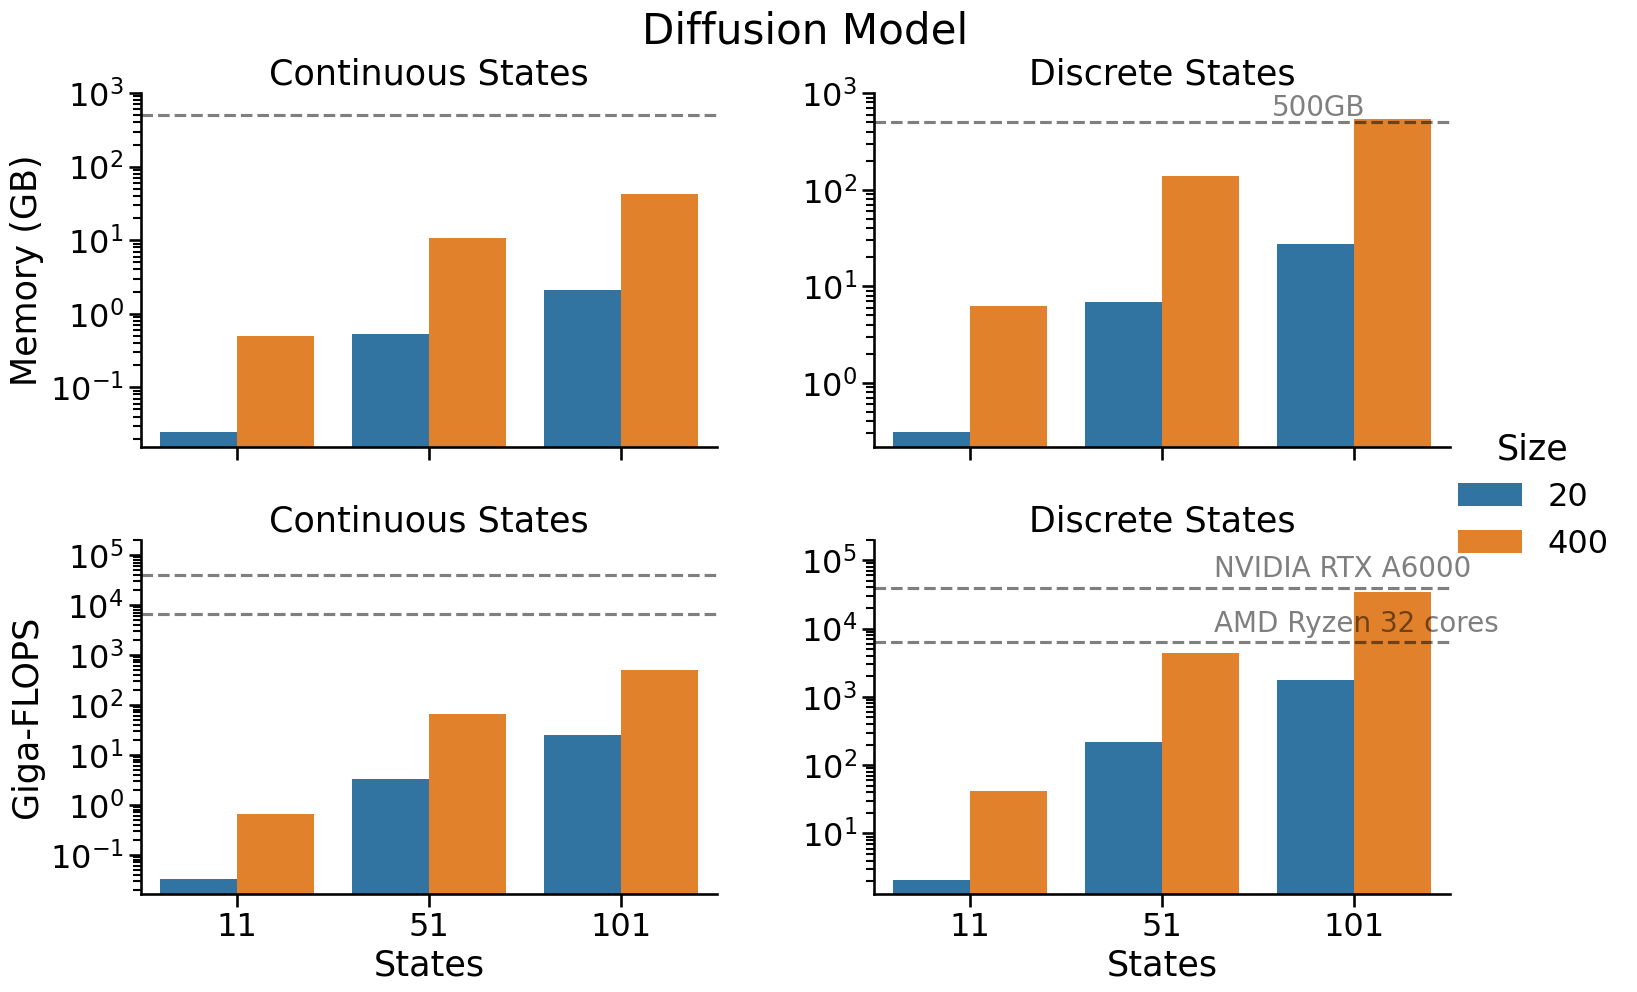

In [8]:
with sns.plotting_context("talk", font_scale=1.4):
    f = sns.catplot(
                df_memory_plot.query("Model=='Markov'").melt(id_vars=df_memory_plot.columns.drop(["bytes_accessed", "flops"]), var_name="func") \
                .assign(func = lambda df: df.func.map({"flops":"Giga-FLOPS", "bytes_accessed":"Memory (GB)"})) \
                .assign(I = lambda df: df.I.astype(str))
                ,
    x="States",
    y="value",
    col="state", #col_order=["Likelihood", "Likelihood Gradient"],
    hue="I",
    row="func",
    kind="bar", aspect=1.5, legend=True, sharey=False
    )
    f.figure.suptitle("Diffusion Model", y=1.01)
    f.legend.set_title("Size")
    f.set(yscale="log")
    f.axes[0,0].set_ylabel("Memory (GB)")
    f.axes[1,0].set_ylabel("Giga-FLOPS")
    f.set_xlabels("States")
    f.set_titles("{col_name} States")
    f.axes[0,0].axhline(y=500, ls="--", alpha=0.5, color="black")
    f.axes[0,1].axhline(y=500, ls="--", alpha=0.5, color="black")
    f.axes[0,1].text(x=1.57, y=580, s="500GB", alpha=0.5, color="black", size=20)
    #f.set_titles(col_template="")
    f.axes[1,0].axhline(y=38.71*1000, ls="--", alpha=0.5, color="black") #38.71 TFLOPS
    f.axes[1,0].axhline(y=6451.2, ls="--", alpha=0.5, color="black") # AMD Threadripper
    f.axes[1,1].axhline(y=38.71*1000, ls="--", alpha=0.5, color="black") #38.71 TFLOPS
    f.axes[1,1].axhline(y=6451.2, ls="--", alpha=0.5, color="black") # AMD Threadripper
    #f.legend.set_title("Participants")
    f.axes[1,1].text(y=38.71*1500, x=1.27, s="NVIDIA RTX A6000", alpha=0.5, size=20) #https://www.techpowerup.com/gpu-specs/rtx-a6000.c3686 
    f.axes[1,1].text(y=8900, x=1.27, s="AMD Ryzen 32 cores", alpha=0.5, size=20) #https://www.techpowerup.com/cpu-specs/ryzen-threadripper-pro-3975wx.c2315#:~:text=6%2C451.2,GFLOPS
    #f.set(ylim=(None, 100000))
    f.axes[0,0].set_ylim((None, 1000))
    f.axes[0,1].set_ylim((None, 1000))

    f.axes[1,0].set_ylim((None, 200000))
    f.axes[1,1].set_ylim((None, 200000))
    

In [101]:
arr = np.ones((400, 50, 425, 425))
(arr.itemsize * arr.size) / 1000000000

28.9